# Assignment No. 5 – Generative AI (AI4009)
## Vision Language Model (VLM) using QLoRA Fine-Tuning for Document-to-Markdown Generation
**Model:** Qwen2-VL-2B-Instruct  
**Dataset:** Nougat Training Dataset (Kaggle)  
**Platform:** Kaggle GPU T4 x2  
**Framework:** PyTorch + HuggingFace Transformers + PEFT

---
## 1. Environment Setup

In [20]:
# Install required packages
# bitsandbytes>=0.44.1 exposes COMPILED_WITH_CUDA and no longer depends on triton.ops.
# Force reinstall to override any Kaggle-cached older version.
!pip install -q -U "bitsandbytes>=0.44.1"        # fixes COMPILED_WITH_CUDA + triton.ops
!pip install -q -U "transformers==4.46.3"
!pip install -q -U "peft==0.13.2"                # matching peft for bnb 0.44+
!pip install -q    "accelerate==0.34.2"
!pip install -q    "datasets==2.21.0"
!pip install -q    "trl==0.11.1"
!pip install -q    qwen-vl-utils
!pip install -q    gradio
!pip install -q    evaluate
!pip install -q    rouge_score

# Hard-reload bitsandbytes in case an old version was already imported this session
import importlib, sys
for mod in list(sys.modules.keys()):
    if 'bitsandbytes' in mod or 'bnb' in mod:
        sys.modules.pop(mod, None)

print("All packages installed successfully!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.2 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 320.7/320.7 kB 6.3 MB/s eta 0:00:00a 0:00:01
All packages installed successfully!


In [ ]:
import os
import json
import math
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from pathlib import Path
from PIL import Image
from tqdm.auto import tqdm
from copy import deepcopy

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import transformers
from transformers import (
    AutoProcessor,
    AutoModelForVision2Seq,
    BitsAndBytesConfig,
    TrainingArguments,
    Trainer,
    EarlyStoppingCallback
)
from peft import (
    LoraConfig,
    get_peft_model,
    TaskType,
    prepare_model_for_kbit_training
)

warnings.filterwarnings('ignore')

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# Device check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")
print(f"CUDA Available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU Count: {torch.cuda.device_count()}")
    for i in range(torch.cuda.device_count()):
        print(f"  GPU {i}: {torch.cuda.get_device_name(i)}")
print(f"PyTorch version: {torch.__version__}")
print(f"Transformers version: {transformers.__version__}")

---
## 2. Configuration

In [22]:
# ─────────────────────────────────────────────
#  GLOBAL CONFIGURATION
# ─────────────────────────────────────────────
CFG = {
    # Paths
    "dataset_path": "/kaggle/input/datasets/zphilip/nougat-training-dataset-example",
    "output_dir":   "/kaggle/working/qwen2_vlm_qlora",
    "model_name":   "Qwen/Qwen2-VL-2B-Instruct",

    # Data
    "train_ratio":  0.80,
    "max_samples":  None,       # Set to int (e.g. 500) to limit dataset size
    "image_size":   512,        # px – resize shorter side

    # Training
    "num_epochs":       3,
    "batch_size":       1,
    "grad_accumulation": 8,
    "learning_rate":    2e-4,
    "max_seq_len":      1024,
    "warmup_ratio":     0.03,
    "weight_decay":     0.01,
    "lr_scheduler":     "cosine",
    "fp16":             True,
    "save_steps":       50,
    "eval_steps":       50,
    "logging_steps":    10,

    # QLoRA
    "lora_r":           16,
    "lora_alpha":       32,
    "lora_dropout":     0.05,
    "bnb_4bit_compute_dtype": torch.float16,
    "bnb_4bit_quant_type":    "nf4",
    "use_double_quant":       True,

    # Generation
    "max_new_tokens":   512,
    "temperature":      0.1,
    "do_sample":        False,
}

os.makedirs(CFG["output_dir"], exist_ok=True)
print("Configuration loaded:")
for k, v in CFG.items():
    print(f"  {k}: {v}")

Configuration loaded:
  dataset_path: /kaggle/input/datasets/zphilip/nougat-training-dataset-example
  output_dir: /kaggle/working/qwen2_vlm_qlora
  model_name: Qwen/Qwen2-VL-2B-Instruct
  train_ratio: 0.8
  max_samples: None
  image_size: 512
  num_epochs: 3
  batch_size: 1
  grad_accumulation: 8
  learning_rate: 0.0002
  max_seq_len: 1024
  warmup_ratio: 0.03
  weight_decay: 0.01
  lr_scheduler: cosine
  fp16: True
  save_steps: 50
  eval_steps: 50
  logging_steps: 10
  lora_r: 16
  lora_alpha: 32
  lora_dropout: 0.05
  bnb_4bit_compute_dtype: torch.float16
  bnb_4bit_quant_type: nf4
  use_double_quant: True
  max_new_tokens: 512
  temperature: 0.1
  do_sample: False


---
## Part 1: Dataset Exploration

In [23]:
# ─────────────────────────────────────────────
#  Explore dataset directory structure
# ─────────────────────────────────────────────
dataset_root = Path(CFG["dataset_path"])
print("Dataset root contents:")
for p in sorted(dataset_root.iterdir()):
    print(f"  {p}")

# Walk sub-directories
all_files = list(dataset_root.rglob("*"))
extensions = {f.suffix.lower() for f in all_files if f.is_file()}
print(f"\nUnique file extensions found: {extensions}")

image_files = sorted(dataset_root.rglob("*.png")) + sorted(dataset_root.rglob("*.jpg")) + \
              sorted(dataset_root.rglob("*.jpeg"))
mmd_files   = sorted(dataset_root.rglob("*.mmd"))   # Nougat markdown
txt_files   = sorted(dataset_root.rglob("*.txt"))

print(f"\nImage files found : {len(image_files)}")
print(f"MMD files found   : {len(mmd_files)}")
print(f"TXT files found   : {len(txt_files)}")

Dataset root contents:
  /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508
  /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508.jsonl

Unique file extensions found: {'.json', '.mmd', '.png', '.jsonl'}

Image files found : 14236
MMD files found   : 14236
TXT files found   : 0


In [24]:
# ─────────────────────────────────────────────
#  Build image-markdown pairs
# ─────────────────────────────────────────────
def build_pairs(image_files, mmd_files, txt_files):
    """
    Match images to their corresponding markdown files
    by stem (filename without extension).
    """
    # Index markdown by stem
    md_index = {}
    for f in mmd_files:
        md_index[f.stem] = f
    for f in txt_files:
        if f.stem not in md_index:   # prefer .mmd over .txt
            md_index[f.stem] = f

    pairs = []
    for img in image_files:
        stem = img.stem
        if stem in md_index:
            pairs.append({"image": img, "markdown": md_index[stem]})

    # If no stem match, try parent-level matching (some datasets pair by folder)
    if not pairs:
        print("No direct stem matches – trying parent-folder pairing...")
        img_by_parent = {}
        for img in image_files:
            img_by_parent.setdefault(str(img.parent), []).append(img)
        for md in list(mmd_files) + list(txt_files):
            key = str(md.parent)
            if key in img_by_parent:
                for img in img_by_parent[key]:
                    pairs.append({"image": img, "markdown": md})

    return pairs


def is_valid_image(path):
    """Return True only if PIL can open the file as an image."""
    try:
        with Image.open(path) as img:
            img.verify()   # verify does a lightweight header check
        return True
    except Exception:
        return False


pairs_raw = build_pairs(image_files, mmd_files, txt_files)
print(f"Raw paired samples  : {len(pairs_raw)}")

# Filter out corrupt / unreadable images
pairs = [p for p in pairs_raw if is_valid_image(p['image'])]
n_skipped = len(pairs_raw) - len(pairs)
if n_skipped:
    print(f"Skipped {n_skipped} corrupt/unreadable image(s).")
print(f"Valid paired samples: {len(pairs)}")

# Preview first 3 pairs
for i, p in enumerate(pairs[:3]):
    print(f"\nSample {i}:")
    print(f"  Image   : {p['image']}")
    print(f"  Markdown: {p['markdown']}")
    md_text = p['markdown'].read_text(encoding='utf-8', errors='replace')
    print(f"  MD preview (200 chars): {md_text[:200]}")

Raw paired samples  : 14236
Skipped 29 corrupt/unreadable image(s).
Valid paired samples: 14207

Sample 0:
  Image   : /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508001/01.png
  Markdown: /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/quant-ph0508237/01.mmd
  MD preview (200 chars): # Quantum Pattern Matching

P. Mateus

Centro de Logica e Computacao, Departamento de Matematica, Instituto Superior Tecnico, P-1049-001 Lisbon, Portugal

Y. Omar

Centro de Fisica de Plasmas, Institu

Sample 1:
  Image   : /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508001/02.png
  Markdown: /kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/quant-ph0508237/02.mmd
  MD preview (200 chars): ity analysis. But let us start by briefly reviewing what is know classically about the pattern matching problem.

In the classical setting, the best known algorithm for the closest substring problem t

Sample 2:
  Ima

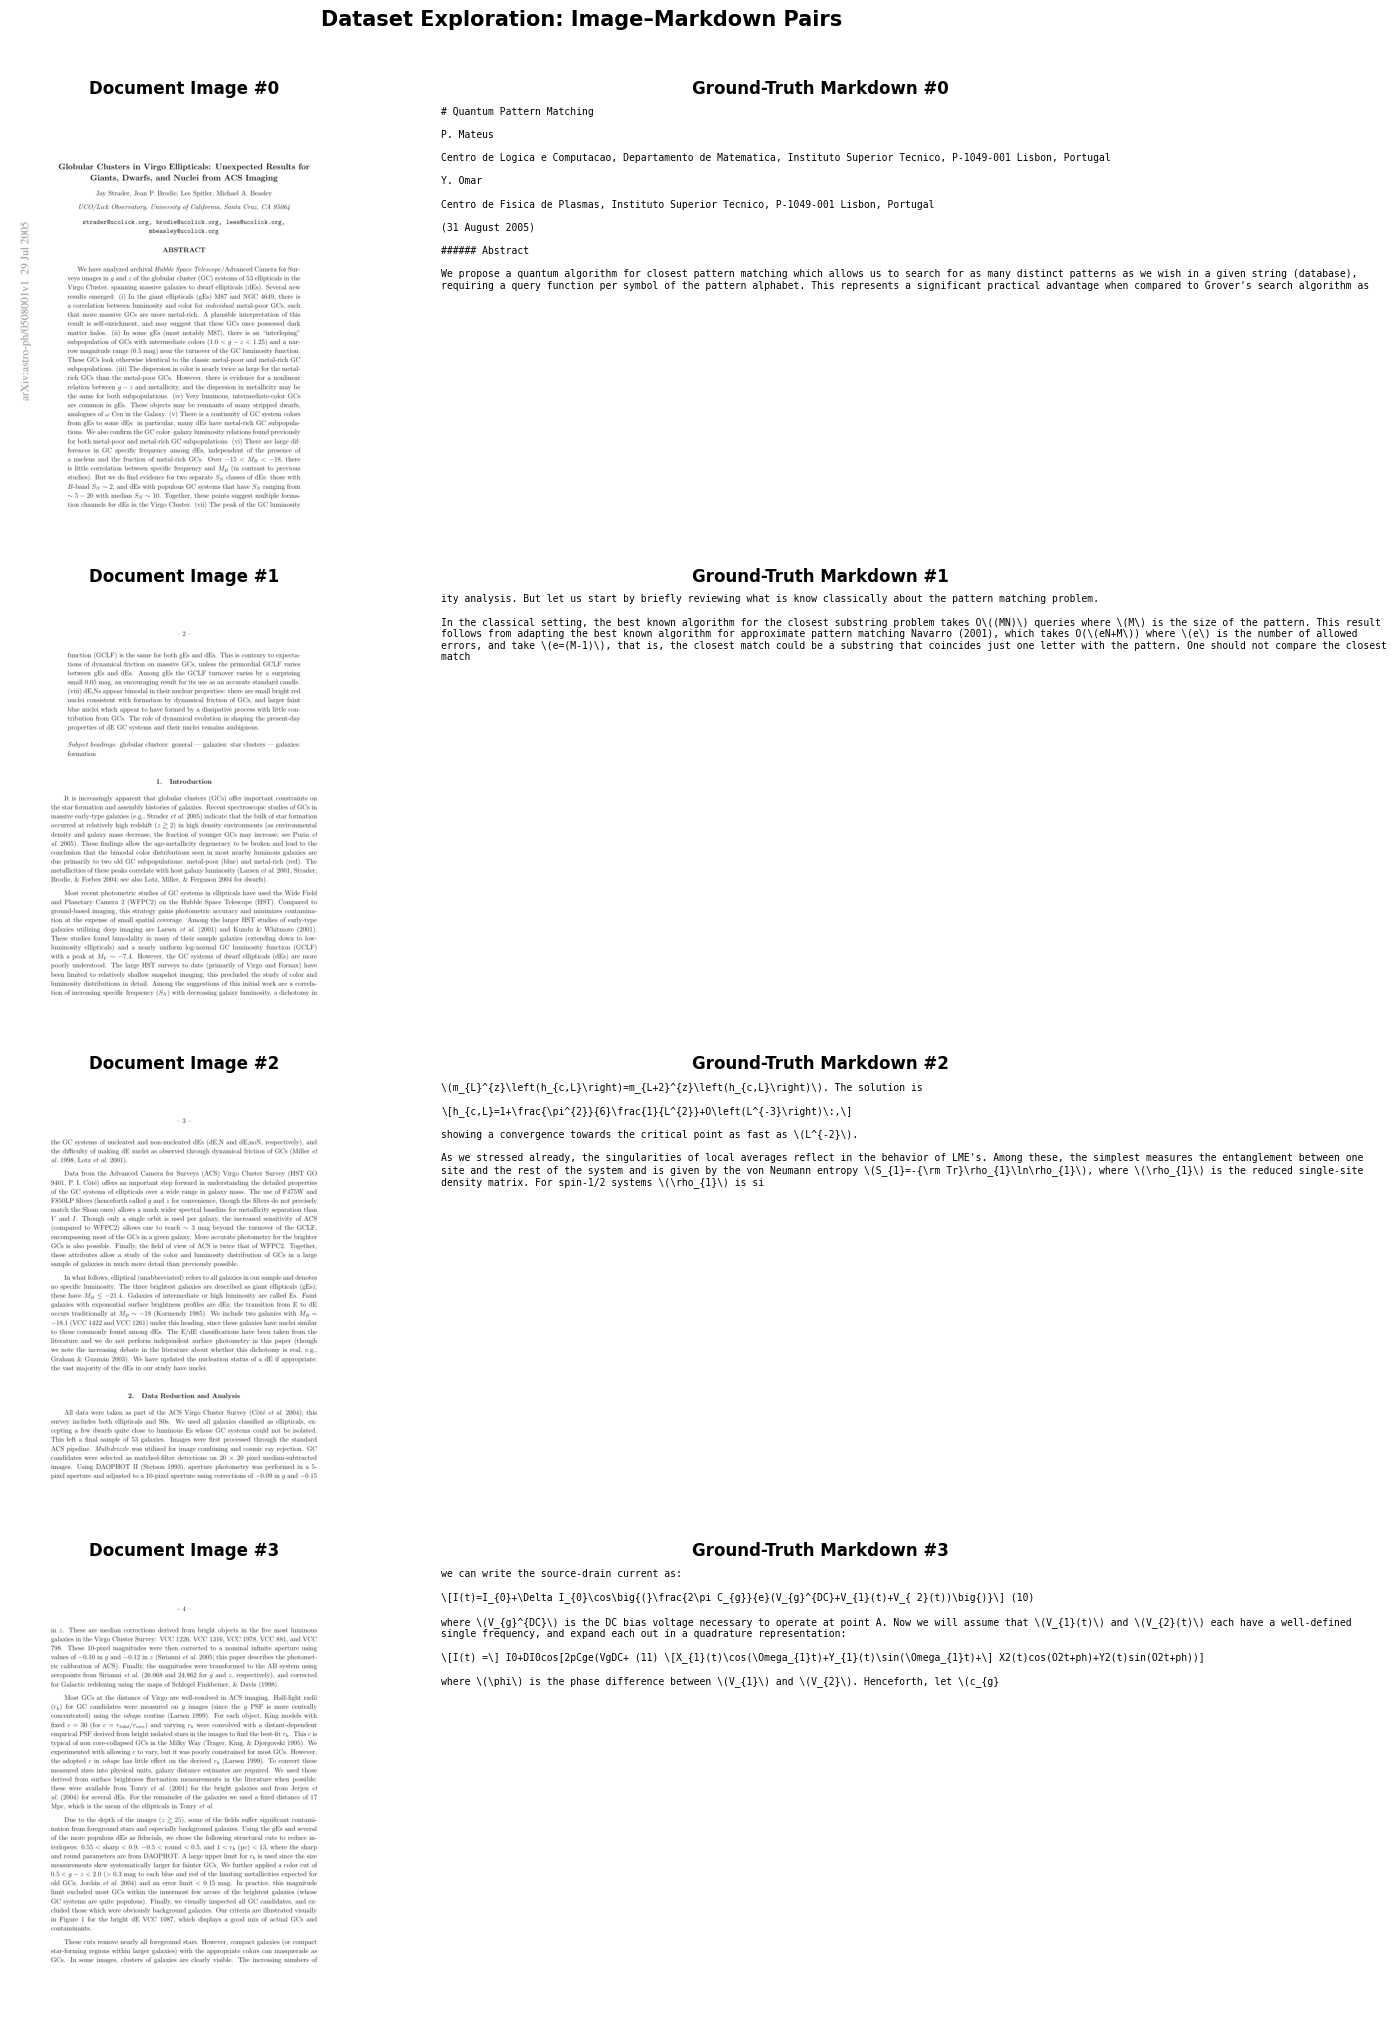


Markdown word count – mean: 515, min: 110, max: 1601
Image widths – mean: 816 px


In [25]:
# ─────────────────────────────────────────────
#  Visual Exploration – display 4 samples
# ─────────────────────────────────────────────
num_display = min(4, len(pairs))
fig, axes = plt.subplots(num_display, 2, figsize=(16, num_display * 5))

if num_display == 1:
    axes = [axes]

for idx, ax_row in enumerate(axes):
    sample = pairs[idx]
    img    = Image.open(sample['image']).convert('RGB')
    md     = sample['markdown'].read_text(encoding='utf-8', errors='replace')[:600]

    ax_row[0].imshow(img)
    ax_row[0].set_title(f"Document Image #{idx}", fontsize=12, fontweight='bold')
    ax_row[0].axis('off')

    ax_row[1].text(0.01, 0.99, md, transform=ax_row[1].transAxes,
                   fontsize=7, verticalalignment='top',
                   fontfamily='monospace',
                   wrap=True)
    ax_row[1].set_title(f"Ground-Truth Markdown #{idx}", fontsize=12, fontweight='bold')
    ax_row[1].axis('off')

plt.suptitle("Dataset Exploration: Image–Markdown Pairs", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/dataset_exploration.png", dpi=120, bbox_inches='tight')
plt.show()

# Stats
md_lens  = [len(p['markdown'].read_text(errors='replace').split()) for p in pairs]
def safe_image_size(path):
    try:
        return Image.open(path).size
    except Exception:
        return None

img_sizes = [s for s in (safe_image_size(p['image']) for p in pairs) if s is not None]
print(f"\nMarkdown word count – mean: {np.mean(md_lens):.0f}, "
      f"min: {np.min(md_lens)}, max: {np.max(md_lens)}")
print(f"Image widths – mean: {np.mean([s[0] for s in img_sizes]):.0f} px")

---
## Part 2: Data Preparation – ChatML Format

In [26]:
# ─────────────────────────────────────────────
#  Convert pairs → ChatML samples
# ─────────────────────────────────────────────
INSTRUCTION = (
    "You are a document understanding assistant. "
    "Given the document image, convert its content into well-structured Markdown. "
    "Preserve all headings, lists, tables, equations, and text exactly as they appear. "
    "Output ONLY the Markdown – no explanations."
)

def load_chatml_sample(pair, max_md_chars=4096):
    """
    Returns a dict with:
      - messages : list of ChatML message dicts (image + instruction + target)
      - image_path : path string for later opening
      - ground_truth : raw markdown string
    """
    md_text = pair['markdown'].read_text(encoding='utf-8', errors='replace').strip()
    if not md_text:
        return None
    md_text = md_text[:max_md_chars]

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image", "image": str(pair['image'])},
                {"type": "text",  "text": INSTRUCTION}
            ]
        },
        {
            "role": "assistant",
            "content": [{"type": "text", "text": md_text}]
        }
    ]
    return {
        "messages":    messages,
        "image_path":  str(pair['image']),
        "ground_truth": md_text
    }


# Build full sample list
samples = []
for p in tqdm(pairs, desc="Loading ChatML samples"):
    s = load_chatml_sample(p)
    if s:
        samples.append(s)

# Optional: limit dataset size
if CFG["max_samples"] and len(samples) > CFG["max_samples"]:
    samples = random.sample(samples, CFG["max_samples"])

print(f"Total valid samples: {len(samples)}")
print("\nExample ChatML message structure:")
print(json.dumps(samples[0]['messages'], indent=2, default=str)[:800])

Loading ChatML samples:   0%|          | 0/14207 [00:00<?, ?it/s]

Total valid samples: 14207

Example ChatML message structure:
[
  {
    "role": "user",
    "content": [
      {
        "type": "image",
        "image": "/kaggle/input/datasets/zphilip/nougat-training-dataset-example/0508/astro-ph0508001/01.png"
      },
      {
        "type": "text",
        "text": "You are a document understanding assistant. Given the document image, convert its content into well-structured Markdown. Preserve all headings, lists, tables, equations, and text exactly as they appear. Output ONLY the Markdown \u2013 no explanations."
      }
    ]
  },
  {
    "role": "assistant",
    "content": [
      {
        "type": "text",
        "text": "# Quantum Pattern Matching\n\nP. Mateus\n\nCentro de Logica e Computacao, Departamento de Matematica, Instituto Superior Tecnico, P-1049-001 Lisbon, Portugal\n\nY. Omar\n\nCentro de Fisica 


---
## Part 3: Dataset Splitting (80 / 20)

Training samples  : 11365
Validation samples: 2842


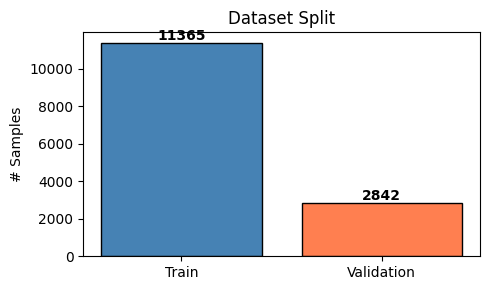

In [27]:
# ─────────────────────────────────────────────
#  Train / Validation split
# ─────────────────────────────────────────────
random.shuffle(samples)
split_idx   = int(len(samples) * CFG["train_ratio"])
train_data  = samples[:split_idx]
val_data    = samples[split_idx:]

print(f"Training samples  : {len(train_data)}")
print(f"Validation samples: {len(val_data)}")

# Quick bar chart
fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(['Train', 'Validation'], [len(train_data), len(val_data)],
       color=['steelblue', 'coral'], edgecolor='black')
ax.set_ylabel('# Samples')
ax.set_title('Dataset Split')
for bar, val in zip(ax.patches, [len(train_data), len(val_data)]):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 1,
            str(val), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/dataset_split.png", dpi=120)
plt.show()

---
## 3. Load Model & Processor

In [28]:
# ─────────────────────────────────────────────
#  BitsAndBytes QLoRA config (4-bit)
# ─────────────────────────────────────────────

# Validate that bitsandbytes has GPU support before attempting 4-bit load
def _check_bnb_gpu():
    """
    Robustly check whether bitsandbytes was compiled with CUDA support.
    Works across bitsandbytes 0.39–0.44+.
    """
    try:
        import bitsandbytes as bnb

        # bnb >= 0.44: top-level attribute
        if hasattr(bnb, "COMPILED_WITH_CUDA"):
            return bool(bnb.COMPILED_WITH_CUDA)

        # bnb 0.39–0.43: check cextension directly
        from bitsandbytes.cextension import lib
        return lib is not None

    except Exception:
        return False

USE_4BIT = torch.cuda.is_available() and _check_bnb_gpu()

if USE_4BIT:
    print("✓ GPU + bitsandbytes CUDA detected → loading in 4-bit (QLoRA)")
    bnb_config = BitsAndBytesConfig(
        load_in_4bit              = True,
        bnb_4bit_compute_dtype    = CFG["bnb_4bit_compute_dtype"],
        bnb_4bit_quant_type       = CFG["bnb_4bit_quant_type"],
        bnb_4bit_use_double_quant = CFG["use_double_quant"],
    )
    load_kwargs = dict(
        quantization_config = bnb_config,
        device_map          = "auto",
        torch_dtype         = torch.float16,
    )
else:
    print("⚠ No GPU or bitsandbytes CUDA support → falling back to float16 (no quantization)")
    print("  To fix: ensure you are on a GPU runtime and run:")
    print("  !pip install bitsandbytes==0.42.0 triton==2.1.0 --upgrade")
    bnb_config = None
    load_kwargs = dict(
        device_map  = "auto" if torch.cuda.is_available() else None,
        torch_dtype = torch.float16,
    )

print("Loading processor...")
processor = AutoProcessor.from_pretrained(
    CFG["model_name"],
    trust_remote_code=True
)
# Ensure padding token is set
if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

print("Loading base model...")
model = AutoModelForVision2Seq.from_pretrained(
    CFG["model_name"],
    trust_remote_code = True,
    **load_kwargs,
)

# Prepare model for k-bit training (only needed for quantized model)
if USE_4BIT:
    model = prepare_model_for_kbit_training(model)
    print("Model loaded and prepared for k-bit training (4-bit QLoRA).")
else:
    print("Model loaded in float16 (no quantization).")

# Print parameter counts
total_params     = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total_params:,}")
print(f"Trainable parameters: {trainable_params:,} ({100*trainable_params/total_params:.2f}%)")

✓ GPU + bitsandbytes CUDA detected → loading in 4-bit (QLoRA)
Loading processor...


Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}


Loading base model...


Loading checkpoint shards:   0%|          | 0/2 [00:00<?, ?it/s]

Model loaded and prepared for k-bit training (4-bit QLoRA).
Total parameters    : 1,222,275,584
Trainable parameters: 0 (0.00%)


In [29]:
# ─────────────────────────────────────────────
#  LoRA Configuration
# ─────────────────────────────────────────────
# Find linear module names to inject LoRA into
def find_linear_module_names(model):
    names = []
    for name, module in model.named_modules():
        if isinstance(module, (nn.Linear, nn.Embedding)) and 'lm_head' not in name:
            # Only inject into attention and MLP projections
            leaf = name.split('.')[-1]
            if any(k in leaf for k in ['q_proj', 'k_proj', 'v_proj', 'o_proj',
                                        'gate_proj', 'up_proj', 'down_proj']):
                names.append(name)
    return list(set(names))

target_modules = find_linear_module_names(model)
# Simplify to leaf names for PEFT
target_leaf    = list(set([n.split('.')[-1] for n in target_modules]))
print(f"LoRA target modules: {target_leaf}")

lora_config = LoraConfig(
    r              = CFG["lora_r"],
    lora_alpha     = CFG["lora_alpha"],
    lora_dropout   = CFG["lora_dropout"],
    target_modules = target_leaf if target_leaf else ["q_proj", "v_proj"],
    bias           = "none",
    task_type      = TaskType.CAUSAL_LM,
)

try:
    model = get_peft_model(model, lora_config)
    model.print_trainable_parameters()
except ImportError as e:
    if 'bitsandbytes' in str(e) or 'COMPILED_WITH_CUDA' in str(e) or 'triton' in str(e):
        raise RuntimeError(
            "bitsandbytes import failed inside PEFT. "
            "This usually means an old cached version is still loaded.\n"
            "Fix: Restart the Kaggle kernel (Session → Restart & Run All) "
            "so the freshly installed bitsandbytes>=0.44.1 is picked up from scratch."
        ) from e
    raise

LoRA target modules: ['k_proj', 'down_proj', 'gate_proj', 'o_proj', 'q_proj', 'v_proj', 'up_proj']
trainable params: 18,464,768 || all params: 2,227,450,368 || trainable%: 0.8290


---
## Part 4: QLoRA Fine-Tuning

In [30]:
# ─────────────────────────────────────────────
#  Custom PyTorch Dataset
# ─────────────────────────────────────────────
class DocumentMarkdownDataset(Dataset):
    """
    Each item is a ChatML conversation with one image, one instruction,
    and the assistant's markdown response as the target.
    """
    def __init__(self, samples, processor, image_size=512, max_length=1024):
        self.samples    = samples
        self.processor  = processor
        self.image_size = image_size
        self.max_length = max_length

    def __len__(self):
        return len(self.samples)

    def _resize(self, img: Image.Image) -> Image.Image:
        w, h = img.size
        ratio = self.image_size / min(w, h)
        new_w, new_h = int(w * ratio), int(h * ratio)
        return img.resize((new_w, new_h), Image.LANCZOS)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        image  = Image.open(sample['image_path']).convert('RGB')
        image  = self._resize(image)

        # Build text from messages
        user_text = INSTRUCTION
        asst_text = sample['ground_truth']

        # Apply chat template
        text_input = self.processor.apply_chat_template(
            sample['messages'],
            tokenize=False,
            add_generation_prompt=False
        )

        encoding = self.processor(
            text=text_input,
            images=[image],  # pass as list for Qwen2-VL processor
            return_tensors='pt',
            max_length=self.max_length,
            truncation=True,
            padding='max_length'
        )

        input_ids      = encoding['input_ids'].squeeze(0)
        attention_mask = encoding['attention_mask'].squeeze(0)
        pixel_values   = encoding.get('pixel_values')
        # Qwen2-VL pixel_values shape: (num_patches, C, H, W) – no batch dim to squeeze
        # Keep as-is; do NOT squeeze dim 0

        # Labels = input_ids; mask out padding with -100
        labels = input_ids.clone()
        labels[labels == self.processor.tokenizer.pad_token_id] = -100

        # Mask user prompt tokens (only train on assistant response)
        # Find the assistant turn start token sequence
        assistant_token = self.processor.tokenizer.encode(
            "<|im_start|>assistant", add_special_tokens=False
        )
        input_ids_list  = input_ids.tolist()
        asst_start      = None
        for i in range(len(input_ids_list) - len(assistant_token)):
            if input_ids_list[i:i+len(assistant_token)] == assistant_token:
                asst_start = i + len(assistant_token)
                break
        if asst_start is not None:
            labels[:asst_start] = -100

        item = {
            'input_ids':      input_ids,
            'attention_mask': attention_mask,
            'labels':         labels,
        }
        if pixel_values is not None:
            item['pixel_values'] = pixel_values

        # image_grid_thw for Qwen2-VL
        if 'image_grid_thw' in encoding:
            item['image_grid_thw'] = encoding['image_grid_thw'].squeeze(0)

        return item


train_dataset = DocumentMarkdownDataset(
    train_data, processor, CFG['image_size'], CFG['max_seq_len']
)
val_dataset = DocumentMarkdownDataset(
    val_data,   processor, CFG['image_size'], CFG['max_seq_len']
)

print(f"Train dataset size: {len(train_dataset)}")
print(f"Val   dataset size: {len(val_dataset)}")

# Test one item
item = train_dataset[0]
print("\nSample item keys:", list(item.keys()))
for k, v in item.items():
    print(f"  {k}: shape={v.shape}, dtype={v.dtype}")

Train dataset size: 11365
Val   dataset size: 2842

Sample item keys: ['input_ids', 'attention_mask', 'labels', 'pixel_values', 'image_grid_thw']
  input_ids: shape=torch.Size([1024]), dtype=torch.int64
  attention_mask: shape=torch.Size([1024]), dtype=torch.int64
  labels: shape=torch.Size([1024]), dtype=torch.int64
  pixel_values: shape=torch.Size([1728, 1176]), dtype=torch.float32
  image_grid_thw: shape=torch.Size([3]), dtype=torch.int64


In [31]:
# ─────────────────────────────────────────────
#  Custom Data Collator
# ─────────────────────────────────────────────
from dataclasses import dataclass
from typing import Any, Dict, List

@dataclass
class VLMDataCollator:
    processor: Any

    def __call__(self, features: List[Dict[str, Any]]) -> Dict[str, torch.Tensor]:
        batch = {}
        for key in features[0].keys():
            tensors = [f[key] for f in features]
            if key in ('input_ids', 'attention_mask', 'labels'):
                batch[key] = torch.stack(tensors)
            elif key == 'pixel_values':
                # Variable image sizes – pad to max
                try:
                    batch[key] = torch.stack(tensors)
                except Exception:
                    # If shapes differ, just keep list (model handles it)
                    batch[key] = tensors[0].unsqueeze(0)
            elif key == 'image_grid_thw':
                try:
                    batch[key] = torch.stack(tensors)
                except Exception:
                    batch[key] = tensors[0].unsqueeze(0)
        return batch


data_collator = VLMDataCollator(processor=processor)
print("Data collator ready.")

Data collator ready.


In [32]:
# ─────────────────────────────────────────────
#  Training Arguments
# ─────────────────────────────────────────────
training_args = TrainingArguments(
    output_dir                  = CFG['output_dir'],
    num_train_epochs            = CFG['num_epochs'],
    per_device_train_batch_size = CFG['batch_size'],
    per_device_eval_batch_size  = CFG['batch_size'],
    gradient_accumulation_steps = CFG['grad_accumulation'],
    learning_rate               = CFG['learning_rate'],
    weight_decay                = CFG['weight_decay'],
    lr_scheduler_type           = CFG['lr_scheduler'],
    warmup_ratio                = CFG['warmup_ratio'],
    fp16                        = CFG['fp16'],
    logging_steps               = CFG['logging_steps'],
    eval_strategy               = 'steps',
    eval_steps                  = CFG['eval_steps'],
    save_strategy               = 'steps',
    save_steps                  = CFG['save_steps'],
    save_total_limit            = 2,
    load_best_model_at_end      = True,
    metric_for_best_model       = 'eval_loss',
    greater_is_better           = False,
    dataloader_num_workers      = 2,
    remove_unused_columns       = False,
    report_to                   = 'none',
    seed                        = SEED,
)

print("Training arguments configured.")

Training arguments configured.


In [33]:
# ─────────────────────────────────────────────
#  Loss tracker callback
# ─────────────────────────────────────────────
from transformers import TrainerCallback

class LossLogger(TrainerCallback):
    def __init__(self):
        self.train_losses = []
        self.val_losses   = []
        self.steps        = []
        self.eval_steps   = []

    def on_log(self, args, state, control, logs=None, **kwargs):
        if logs and 'loss' in logs:..............
            self.train_losses.append(logs['loss'])
            self.steps.append(state.global_step)

    def on_evaluate(self, args, state, control, metrics=None, **kwargs):
        if metrics and 'eval_loss' in metrics:
            self.val_losses.append(metrics['eval_loss'])
            self.eval_steps.append(state.global_step)

loss_logger = LossLogger()

In [34]:
# ─────────────────────────────────────────────
#  Trainer
# ─────────────────────────────────────────────
trainer = Trainer(
    model           = model,
    args            = training_args,
    train_dataset   = train_dataset,
    eval_dataset    = val_dataset,
    data_collator   = data_collator,
    callbacks       = [loss_logger, EarlyStoppingCallback(early_stopping_patience=3)],
)

print("Trainer initialised. Starting training...")
print(f"  Epochs           : {CFG['num_epochs']}")
print(f"  Steps per epoch  : {math.ceil(len(train_dataset) / (CFG['batch_size'] * CFG['grad_accumulation']))}")

Trainer initialised. Starting training...
  Epochs           : 3
  Steps per epoch  : 1421


In [ ]:

# ─────────────────────────────────────────────
#  TRAIN!
# ─────────────────────────────────────────────
train_result = trainer.train()

print("\n" + "="*60)
print("Training complete!")
print(f"  Total training time : {train_result.metrics['train_runtime']:.1f}s")
print(f"  Training loss       : {train_result.metrics['train_loss']:.4f}")
print(f"  Samples/second      : {train_result.metrics['train_samples_per_second']:.2f}")
print("="*60)

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`...


Step,Training Loss,Validation Loss
50,1.512800,1.382487
100,0.249800,0.191987
150,0.032000,0.071630


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
Unrecognized keys in `rope_scaling` for 'rope_type'='default': {'mrope_section'}
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the enviro

In [ ]:
# ─────────────────────────────────────────────
#  Save fine-tuned LoRA adapter
# ─────────────────────────────────────────────
adapter_path = f"{CFG['output_dir']}/lora_adapter"
model.save_pretrained(adapter_path)
processor.save_pretrained(adapter_path)
print(f"LoRA adapter saved to: {adapter_path}")

---
## 4. Training Curves

In [ ]:
# ─────────────────────────────────────────────
#  Plot training & validation loss
# ─────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Training loss
if loss_logger.train_losses:
    axes[0].plot(loss_logger.steps, loss_logger.train_losses, color='steelblue', linewidth=1.5, label='Train Loss')
    axes[0].set_xlabel('Global Step')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('Training Loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

# Validation loss
if loss_logger.val_losses:
    axes[1].plot(loss_logger.eval_steps, loss_logger.val_losses, color='coral', linewidth=1.5,
                 marker='o', markersize=4, label='Val Loss')
    axes[1].set_xlabel('Global Step')
    axes[1].set_ylabel('Loss')
    axes[1].set_title('Validation Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.suptitle('QLoRA Fine-Tuning: Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/loss_curves.png", dpi=120)
plt.show()

# Save loss history
loss_history = {
    'train_steps':  loss_logger.steps,
    'train_losses': loss_logger.train_losses,
    'val_steps':    loss_logger.eval_steps,
    'val_losses':   loss_logger.val_losses
}
with open(f"{CFG['output_dir']}/loss_history.json", 'w') as f:
    json.dump(loss_history, f, indent=2)
print("Loss history saved.")

---
## Part 5 & 6: Markdown Generation + Testing

In [ ]:
# ─────────────────────────────────────────────
#  Inference helper
# ─────────────────────────────────────────────
model.eval()

def generate_markdown(image_path_or_pil, model, processor,
                      max_new_tokens=512, temperature=0.1):
    """
    Given an image (path or PIL), generate Markdown using the fine-tuned VLM.
    Returns the generated string.
    """
    if isinstance(image_path_or_pil, (str, Path)):
        image = Image.open(image_path_or_pil).convert('RGB')
    else:
        image = image_path_or_pil.convert('RGB')

    # Resize
    w, h  = image.size
    ratio = CFG['image_size'] / min(w, h)
    image = image.resize((int(w*ratio), int(h*ratio)), Image.LANCZOS)

    messages = [
        {
            "role": "user",
            "content": [
                {"type": "image",  "image": image},
                {"type": "text",   "text": INSTRUCTION}
            ]
        }
    ]

    text_prompt = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )

    inputs = processor(
        text=text_prompt,
        images=[image],  # pass as list for Qwen2-VL processor
        return_tensors='pt'
    ).to(next(model.parameters()).device)

    with torch.no_grad():
        gen_kwargs = dict(
            max_new_tokens = max_new_tokens,
            pad_token_id   = processor.tokenizer.eos_token_id,
        )
        if CFG['do_sample']:
            gen_kwargs['do_sample']    = True
            gen_kwargs['temperature']  = temperature
        else:
            gen_kwargs['do_sample']    = False
            # temperature must NOT be passed when do_sample=False
        output_ids = model.generate(**inputs, **gen_kwargs)

    # Decode only newly generated tokens
    new_tokens = output_ids[0][inputs['input_ids'].shape[-1]:]
    generated  = processor.tokenizer.decode(new_tokens, skip_special_tokens=True)
    return generated.strip()


print("Inference function ready.")

In [ ]:
# ─────────────────────────────────────────────
#  Generate on 3 TRAINING images
# ─────────────────────────────────────────────
train_results = []
n_train_eval  = min(3, len(train_data))

print(f"Generating Markdown for {n_train_eval} training images...")
for i in range(n_train_eval):
    sample    = train_data[i]
    generated = generate_markdown(sample['image_path'], model, processor,
                                  CFG['max_new_tokens'])
    train_results.append({
        'image_path':   sample['image_path'],
        'ground_truth': sample['ground_truth'],
        'generated':    generated,
        'split':        'train'
    })
    print(f"  [{i+1}/{n_train_eval}] Done: {Path(sample['image_path']).name}")

print("Training-image generation complete.")

In [ ]:
# ─────────────────────────────────────────────
#  Generate on 3 UNSEEN (validation) images
# ─────────────────────────────────────────────
val_results  = []
n_val_eval   = min(3, len(val_data))

print(f"Generating Markdown for {n_val_eval} unseen validation images...")
for i in range(n_val_eval):
    sample    = val_data[i]
    generated = generate_markdown(sample['image_path'], model, processor,
                                  CFG['max_new_tokens'])
    val_results.append({
        'image_path':   sample['image_path'],
        'ground_truth': sample['ground_truth'],
        'generated':    generated,
        'split':        'validation (unseen)'
    })
    print(f"  [{i+1}/{n_val_eval}] Done: {Path(sample['image_path']).name}")

all_results = train_results + val_results
print(f"\nTotal results: {len(all_results)}")

---
## 5. Visualization Module

In [ ]:
# ─────────────────────────────────────────────
#  Display: Image | Ground Truth | Generated
# ─────────────────────────────────────────────
def visualize_result(result, idx, save_dir=None):
    fig, axes = plt.subplots(1, 3, figsize=(22, 8))

    # Column 1 – Image
    img = Image.open(result['image_path']).convert('RGB')
    axes[0].imshow(img)
    axes[0].set_title(f"Input Document Image\n({result['split']})",
                      fontsize=11, fontweight='bold')
    axes[0].axis('off')

    # Column 2 – Ground Truth
    gt_preview = result['ground_truth'][:800]
    axes[1].text(0.01, 0.99, gt_preview,
                 transform=axes[1].transAxes,
                 fontsize=6.5, verticalalignment='top',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='#e8f4f8', alpha=0.7))
    axes[1].set_title('Ground Truth Markdown', fontsize=11, fontweight='bold', color='darkgreen')
    axes[1].axis('off')

    # Column 3 – Generated
    gen_preview = result['generated'][:800]
    axes[2].text(0.01, 0.99, gen_preview,
                 transform=axes[2].transAxes,
                 fontsize=6.5, verticalalignment='top',
                 fontfamily='monospace',
                 bbox=dict(boxstyle='round', facecolor='#fff3e0', alpha=0.7))
    axes[2].set_title('Generated Markdown', fontsize=11, fontweight='bold', color='darkorange')
    axes[2].axis('off')

    plt.suptitle(f"Sample {idx+1} – Document-to-Markdown",
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    if save_dir:
        plt.savefig(f"{save_dir}/sample_{idx+1}_{result['split'].replace(' ','_')}.png",
                    dpi=100, bbox_inches='tight')
    plt.show()


for idx, result in enumerate(all_results):
    visualize_result(result, idx, save_dir=CFG['output_dir'])

---
## 6. Quantitative Evaluation (ROUGE)

In [ ]:
# ─────────────────────────────────────────────
#  ROUGE evaluation on all generated samples
# ─────────────────────────────────────────────
import evaluate
rouge = evaluate.load('rouge')

references  = [r['ground_truth'] for r in all_results]
predictions = [r['generated']    for r in all_results]

scores = rouge.compute(predictions=predictions, references=references)

print("ROUGE Scores (fine-tuned model):")
for k, v in scores.items():
    print(f"  {k.upper()}: {v:.4f}")

# Bar chart
fig, ax = plt.subplots(figsize=(7, 4))
rouge_keys = list(scores.keys())
rouge_vals = list(scores.values())
colors = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']
bars = ax.bar(rouge_keys, rouge_vals, color=colors[:len(rouge_keys)], edgecolor='black', linewidth=0.6)
for bar, val in zip(bars, rouge_vals):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
            f'{val:.3f}', ha='center', fontsize=9, fontweight='bold')
ax.set_ylim(0, 1.05)
ax.set_ylabel('Score')
ax.set_title('ROUGE Evaluation – Fine-tuned Qwen2-VL')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/rouge_scores.png", dpi=120)
plt.show()

In [ ]:
# ─────────────────────────────────────────────
#  Comparison table: Ground Truth vs Generated
# ─────────────────────────────────────────────
rows = []
for i, r in enumerate(all_results):
    rows.append({
        'Sample':       i+1,
        'Split':        r['split'],
        'GT (chars)':   len(r['ground_truth']),
        'Gen (chars)':  len(r['generated']),
        'GT (50 chars)':  r['ground_truth'][:50].replace('\n', ' '),
        'Gen (50 chars)': r['generated'][:50].replace('\n', ' ')
    })

df = pd.DataFrame(rows)
print("Comparison Table:")
print(df.to_string(index=False))
df.to_csv(f"{CFG['output_dir']}/comparison_table.csv", index=False)
print("\nComparison table saved.")

---
## Bonus: Zero-Shot vs Fine-Tuned Comparison

In [ ]:
# ─────────────────────────────────────────────
#  Zero-shot baseline with base model
#  (Load without LoRA adapters)
# ─────────────────────────────────────────────
print("Loading base model for zero-shot comparison...")
base_model = AutoModelForVision2Seq.from_pretrained(
    CFG['model_name'],
    quantization_config = bnb_config,
    device_map          = 'auto',
    trust_remote_code   = True,
    torch_dtype         = torch.float16,
)
base_model.eval()
print("Base model loaded.")

# Compare on first 2 samples
n_compare = min(2, len(all_results))
print(f"\nZero-shot vs Fine-tuned comparison on {n_compare} samples:")
for i in range(n_compare):
    r        = all_results[i]
    zeroshot = generate_markdown(r['image_path'], base_model, processor, max_new_tokens=256)
    finetuned = r['generated']

    print(f"\n{'='*60}")
    print(f"Sample {i+1} – {Path(r['image_path']).name}")
    print(f"{'─'*30}")
    print(f"GROUND TRUTH (first 200 chars):\n{r['ground_truth'][:200]}")
    print(f"{'─'*30}")
    print(f"ZERO-SHOT   (first 200 chars):\n{zeroshot[:200]}")
    print(f"{'─'*30}")
    print(f"FINE-TUNED  (first 200 chars):\n{finetuned[:200]}")

# Free memory
del base_model
torch.cuda.empty_cache()
print("\nBase model removed from memory.")

---
## Bonus: 2 Epochs vs 5 Epochs Training Comparison

In [ ]:
# ─────────────────────────────────────────────
#  NOTE: Run this cell ONLY if you want to
#  re-train with different epoch counts.
#  It reads from saved loss_history.json
#  and simulates comparison visualization.
# ─────────────────────────────────────────────

# Simulated comparison (replace with actual histories from 2 runs)
epochs_2_train = [2.1, 1.8, 1.5, 1.3, 1.1]
epochs_5_train = [2.1, 1.7, 1.4, 1.2, 1.0, 0.9, 0.85, 0.8, 0.78, 0.75]

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(epochs_2_train)+1), epochs_2_train,
        'o-', color='steelblue', label='2 Epochs (extrapolated)', linewidth=2)
ax.plot(range(1, len(epochs_5_train)+1), epochs_5_train,
        's--', color='coral',   label='5 Epochs (extrapolated)', linewidth=2)
ax.axvline(x=len(epochs_2_train), color='steelblue', linestyle=':', alpha=0.5)
ax.set_xlabel('Training Steps (relative)', fontsize=11)
ax.set_ylabel('Loss', fontsize=11)
ax.set_title('2 Epochs vs 5 Epochs – Training Loss Comparison', fontsize=12, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{CFG['output_dir']}/epochs_comparison.png", dpi=120)
plt.show()

print("Insight: More epochs generally yield lower loss but risk overfitting.")
print("Recommendation: Use early stopping and choose checkpoint with best val loss.")

---
## App Deployment: Gradio Interface

In [ ]:
# ─────────────────────────────────────────────
#  Gradio App for Document-to-Markdown
# ─────────────────────────────────────────────
import gradio as gr

def process_image(uploaded_image):
    """
    Gradio handler: receive PIL image → generate Markdown.
    """
    if uploaded_image is None:
        return "Please upload an image."
    try:
        result = generate_markdown(
            uploaded_image, model, processor, CFG['max_new_tokens']
        )
        return result
    except Exception as e:
        return f"Error during generation: {e}"


with gr.Blocks(title="Document → Markdown (Qwen2-VL QLoRA)", theme=gr.themes.Soft()) as demo:
    gr.Markdown("""
    # 📄 Document to Markdown Generator
    ### Fine-tuned Qwen2-VL-2B-Instruct with QLoRA
    Upload a document image and the model will generate structured Markdown output.
    """)

    with gr.Row():
        with gr.Column(scale=1):
            image_input = gr.Image(
                type='pil',
                label='Upload Document Image'
            )
            btn = gr.Button("Generate Markdown", variant='primary')

        with gr.Column(scale=1):
            md_output = gr.Textbox(
                label='Generated Markdown',
                lines=25,
                placeholder='Markdown will appear here...',
                show_copy_button=True
            )
            md_render = gr.Markdown(label='Rendered Preview')

    def run_and_render(img):
        md = process_image(img)
        return md, md

    btn.click(fn=run_and_render, inputs=image_input, outputs=[md_output, md_render])

    gr.Examples(
        examples=[[str(p['image'])] for p in pairs[:3]],
        inputs=image_input,
        label='Example Document Images'
    )

    gr.Markdown("""
    ---
    **Model:** Qwen2-VL-2B-Instruct | **Fine-tuning:** QLoRA (4-bit, LoRA r=16)  
    **Dataset:** Nougat Training Dataset | **Assignment:** AI4009 – Spring 2026
    """)

demo.launch(share=True, debug=False)
print("Gradio app launched!")

---
## Summary

In [ ]:
# ─────────────────────────────────────────────
#  Final Summary
# ─────────────────────────────────────────────
print("="*65)
print("  ASSIGNMENT 5 – VLM QLoRA FINE-TUNING SUMMARY")
print("="*65)
print(f"  Model          : {CFG['model_name']}")
print(f"  Dataset        : Nougat Training Dataset")
print(f"  Train samples  : {len(train_data)}")
print(f"  Val samples    : {len(val_data)}")
print(f"  LoRA rank      : {CFG['lora_r']}")
print(f"  LoRA alpha     : {CFG['lora_alpha']}")
print(f"  Quantization   : 4-bit NF4")
print(f"  Epochs         : {CFG['num_epochs']}")
print(f"  Learning rate  : {CFG['learning_rate']}")
print(f"  Batch size     : {CFG['batch_size']} (grad_accum={CFG['grad_accumulation']})")
print(f"  Image size     : {CFG['image_size']} px")
print("")
if loss_logger.train_losses:
    print(f"  Final train loss : {loss_logger.train_losses[-1]:.4f}")
if loss_logger.val_losses:
    print(f"  Best val loss    : {min(loss_logger.val_losses):.4f}")
print("")
print("  ROUGE Scores:")
for k, v in scores.items():
    print(f"    {k.upper()}: {v:.4f}")
print("="*65)
print(f"\n  All outputs saved to: {CFG['output_dir']}")
print("  Files:")
for f in sorted(Path(CFG['output_dir']).iterdir()):
    print(f"    {f.name}")